In [15]:
import numpy as np
import pandas as pd
import os, sys
import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline
import MATS
from scipy import stats

import seaborn as sns
sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set_context("poster")

In [16]:
from MATS.linelistdata import linelistdata
PARAM_LINELIST = linelistdata['O2_ABand_Drouin_2017_linelist']


PARAM_LINELIST['BIA_slope_air'] = 0.0
PARAM_LINELIST['m transition'] = PARAM_LINELIST['m'].copy()
PARAM_LINELIST.loc[PARAM_LINELIST['m'].notna(), 'BIA_slope_air'] = PARAM_LINELIST[PARAM_LINELIST['m'].notna()]['m'].abs()*-0.01196 + 0.49421
PARAM_LINELIST.loc[PARAM_LINELIST['BIA_slope_air']< 0, 'BIA_slope_air'] = 0
PARAM_LINELIST = PARAM_LINELIST[PARAM_LINELIST['m'].notna()]
PARAM_LINELIST['BIA_collision_duration_air'] = 0.75



In [17]:
wave_range = 1.5 #range outside of experimental x-range to simulate
IntensityThreshold = 1e-30 #intensities must be above this value to be simulated
Fit_Intensity = 1e-26 #intensities must be above this value for the line to be fit
order_baseline_fit = 1
sample_molefraction = {7 :0.002022}
wave_min = 13150 #cm-1
wave_max = 13165 #cm-1
wave_space = 0.005 #cm-1
baseline_terms = [0] #polynomial baseline coefficients where the index is equal to the coefficient order
PARAM_LINELIST = PARAM_LINELIST[(PARAM_LINELIST['nu']<=wave_max) & (PARAM_LINELIST['nu']>=wave_min)]

spec_1 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 500,
                     wing_method = 'wing_wavenumbers', wing_wavenumbers = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': False, 'farwing_continuum': 'LBL'})
spec_2 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 1000,
                     wing_method = 'wing_wavenumbers', wing_wavenumbers = 25, filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': False, 'farwing_continuum':  'LBL'})
spec_3 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 1250,
                     wing_method = 'wing_wavenumbers', wing_wavenumbers = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': False, 'farwing_continuum':  'LBL'})
spec_4 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 2500,
                     wing_method = 'wing_wavenumbers', wing_wavenumbers = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': False, 'farwing_continuum':  'LBL'})
spec_5 = MATS.simulate_spectrum(PARAM_LINELIST, wave_min = wave_min, wave_max = wave_max, wave_space = wave_space, 
                     SNR = 5000, baseline_terms = baseline_terms, temperature = 25,  pressure = 5000,
                     wing_method = 'wing_wavenumbers', wing_wavenumbers = 25,  filename = '25_torr', molefraction = sample_molefraction, BIA_model = {'sw_depletion': False, 'farwing_continuum':  'LBL'})



In [22]:
SPECTRA = MATS.Dataset([spec_1, spec_2, spec_3, spec_4, spec_5], 'Fit_Test', PARAM_LINELIST,  BIA_model = {'sw_depletion': False, 'farwing_continuum': 'LBL'})  


FITPARAMS = MATS.Generate_FitParam_File(SPECTRA, lineprofile = 'SDNGP', linemixing = True, 
                          fit_intensity = Fit_Intensity, threshold_intensity = IntensityThreshold, sim_window = wave_range,
                          nu_constrain = True, sw_constrain = True, gamma0_constrain = True, delta0_constrain = True, 
                           aw_constrain = True, as_constrain = True, 
                           nuVC_constrain = True, eta_constrain =True, linemixing_constrain = True,
                            additional_columns = ['trans_id', 'local_lower_quanta', 'm transition'])

FITPARAMS.generate_fit_baseline_linelist(vary_baseline = False, vary_molefraction = {7:False, 1:False}, vary_xshift = False, vary_temperature = False, 
                                      vary_etalon_amp= False, vary_etalon_period= False, vary_etalon_phase= False)

FITPARAMS.generate_fit_param_linelist_from_linelist(vary_nu = {7:{1:False, 2:False, 3:False}}, vary_sw = {7:{1:False, 2:False, 3:False}},
                                                    vary_gamma0 = {7:{1: False, 2:False, 3: False}, 1:{1:False}}, vary_n_gamma0 = {7:{1:False}}, 
                                                    vary_delta0 = {7:{1:False , 2:False, 3: False}, 1:{1:False}}, vary_n_delta0 = {7:{1:False}}, 
                                                    vary_aw = {7:{1: False, 2:False, 3: False}, 1:{1:False}}, vary_n_gamma2 = {7:{1:False}}, 
                                                    vary_as = {}, vary_n_delta2 = {7:{1:False}}, 
                                                    vary_nuVC = {7:{1:False, 2:False}}, vary_n_nuVC = {7:{1:False}},
                                                    vary_eta = {}, vary_linemixing = {7:{1:False}}, 
                                                    vary_BIA_slope = {7:{1:False}}, vary_BIA_collision_duration = {7:{1:False}})



sw_depletion must be true to use LBL farwing continuum feature


,trans_id,local_lower_quanta,m transition,molec_id,local_iso_id,elower,nu,nu_err,nu_vary,sw,...,n_delta2_air,eta_air,eta_air_err,eta_air_vary,y_air,y_air_err,y_air_vary,n_y_air,BIA_slope_air,BIA_collision_duration_air
0,6297222,R 11Q 12 d,13.0,7,1,188.7134,13150.19673,0.0,False,770.20000,...,0,0,0.0,False,-0.000057,0.0,False,1.849878,0.0,0.0
1,6297223,R 13R 13 d,14.0,7,1,262.5827,13151.34876,0.0,False,567.80000,...,0,0,0.0,False,-0.000350,0.0,False,3.389741,0.0,0.0
2,6297224,R 13Q 14 d,15.0,7,1,260.5009,13153.43057,0.0,False,631.30000,...,0,0,0.0,False,-0.000510,0.0,False,1.852150,0.0,0.0
3,6297225,R 15R 15 d,16.0,7,1,345.8495,13154.17894,0.0,False,436.90000,...,0,0,0.0,False,-0.000860,0.0,False,3.020138,0.0,0.0
4,6297226,R 15Q 16 d,17.0,7,1,343.7481,13156.28033,0.0,False,479.90000,...,0,0,0.0,False,-0.001030,0.0,False,1.985142,0.0,0.0
5,6297227,R 17R 17 d,18.0,7,1,440.5618,13156.62333,0.0,False,312.30000,...,0,0,0.0,False,-0.001430,0.0,False,3.137980,0.0,0.0
6,6297229,R 17Q 18 d,19.0,7,1,438.4413,13158.74374,0.0,False,339.90000,...,0,0,0.0,False,-0.001640,0.0,False,2.226020,0.0,0.0
7,6297228,R 19R 19 d,20.0,7,1,546.7042,13158.67919,0.0,False,208.30000,...,0,0,0.0,False,-0.002070,0.0,False,4.257625,0.0,0.0
8,6297232,R 19Q 20 d,21.0,7,1,544.5651,13160.81826,0.0,False,225.00000,...,0,0,0.0,False,-0.002400,0.0,False,2.668600,0.0,0.0
9,6297230,R 21R 21 d,22.0,7,1,664.2595,13160.34357,0.0,False,130.00000,...,0,0,0.0,False,-0.002180,0.0,False,5.229705,0.0,0.0


In [19]:
SPECTRA.BIA_model

{'sw_depletion': True, 'farwing_continuum': 'LBL'}

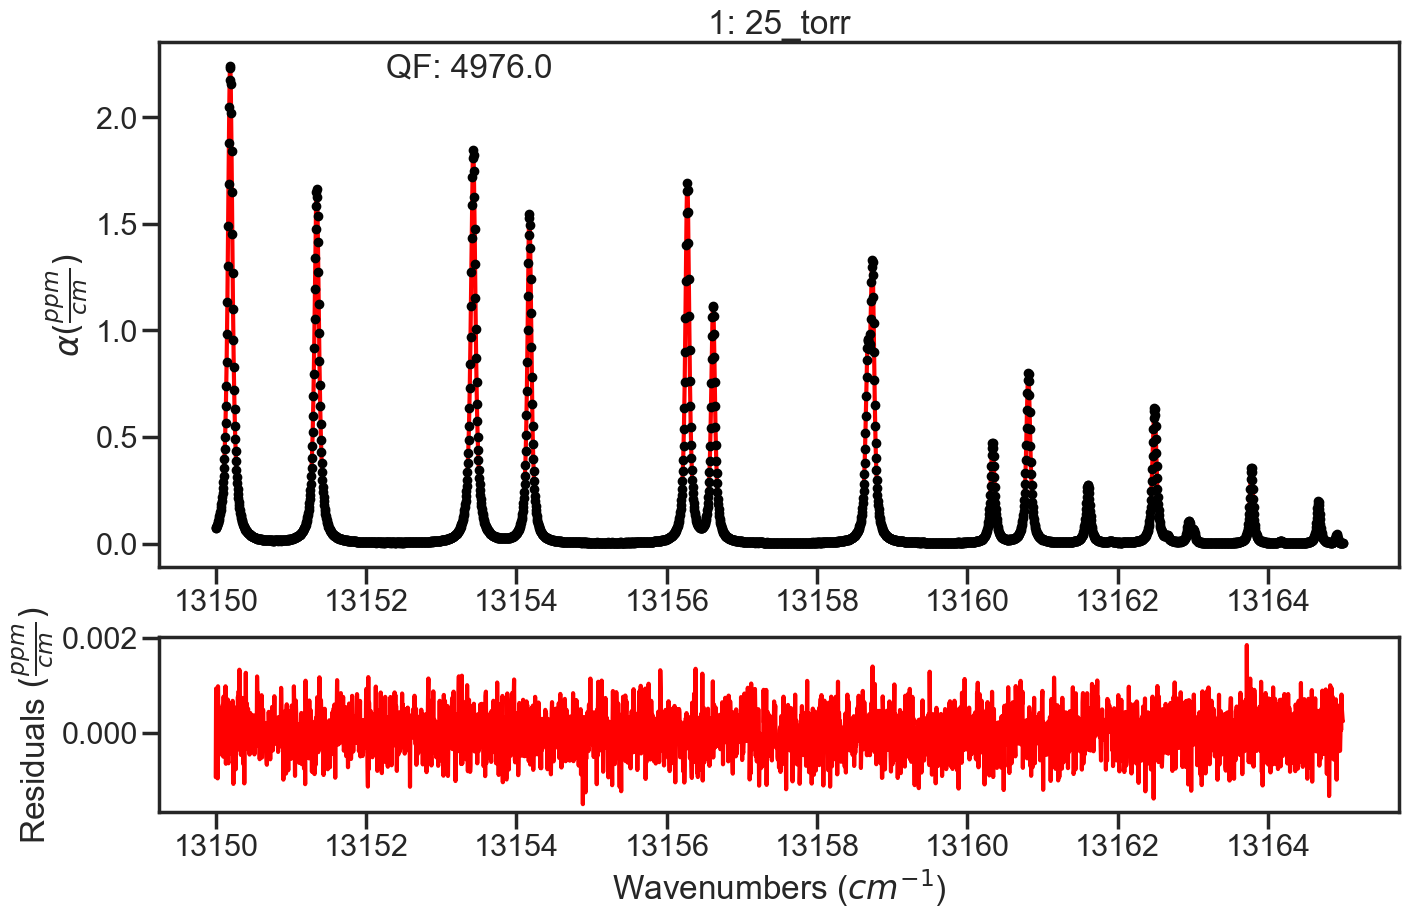

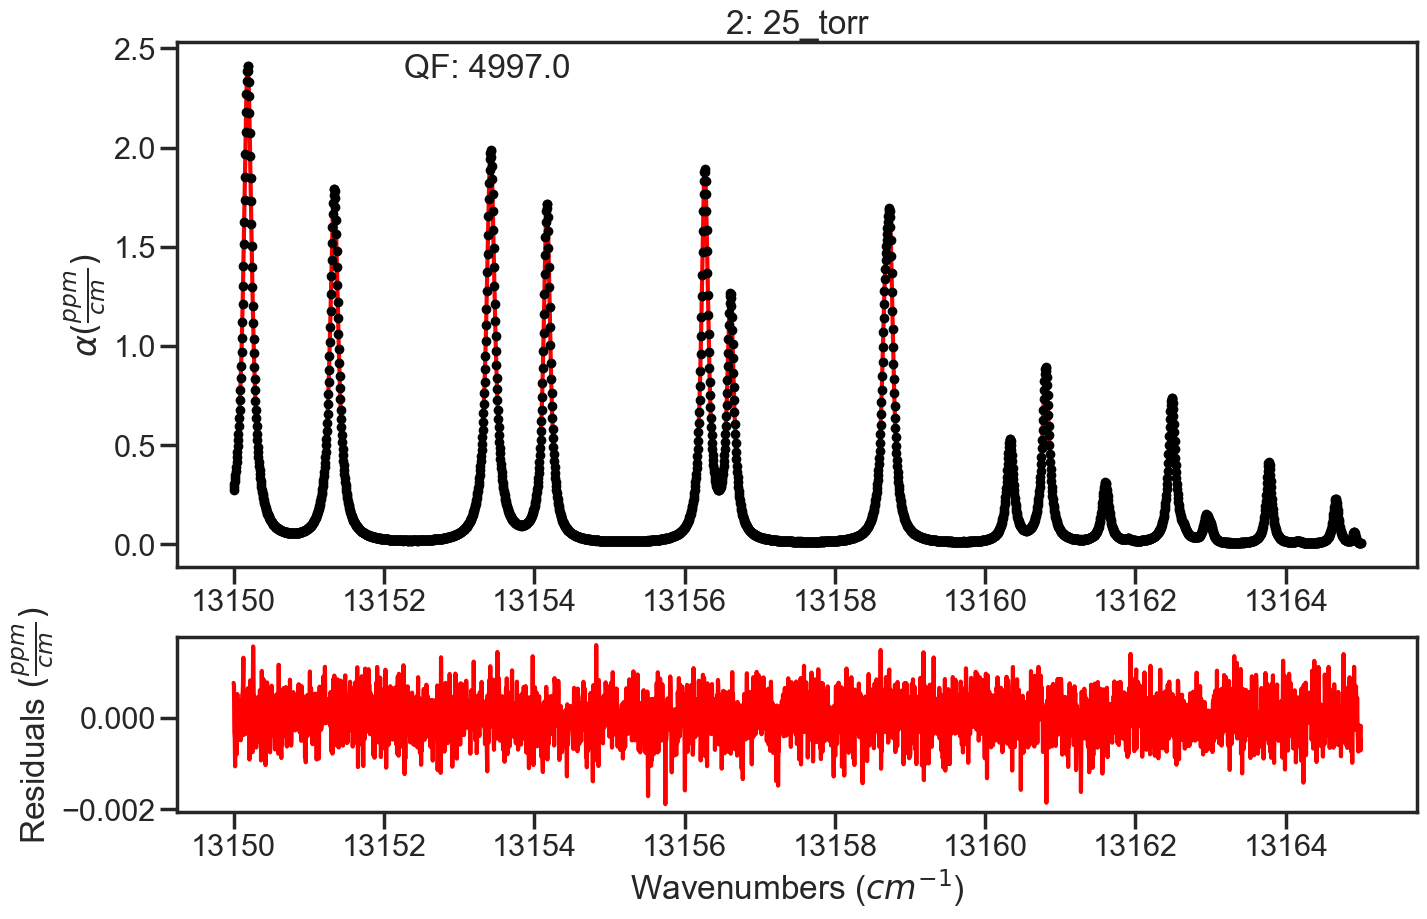

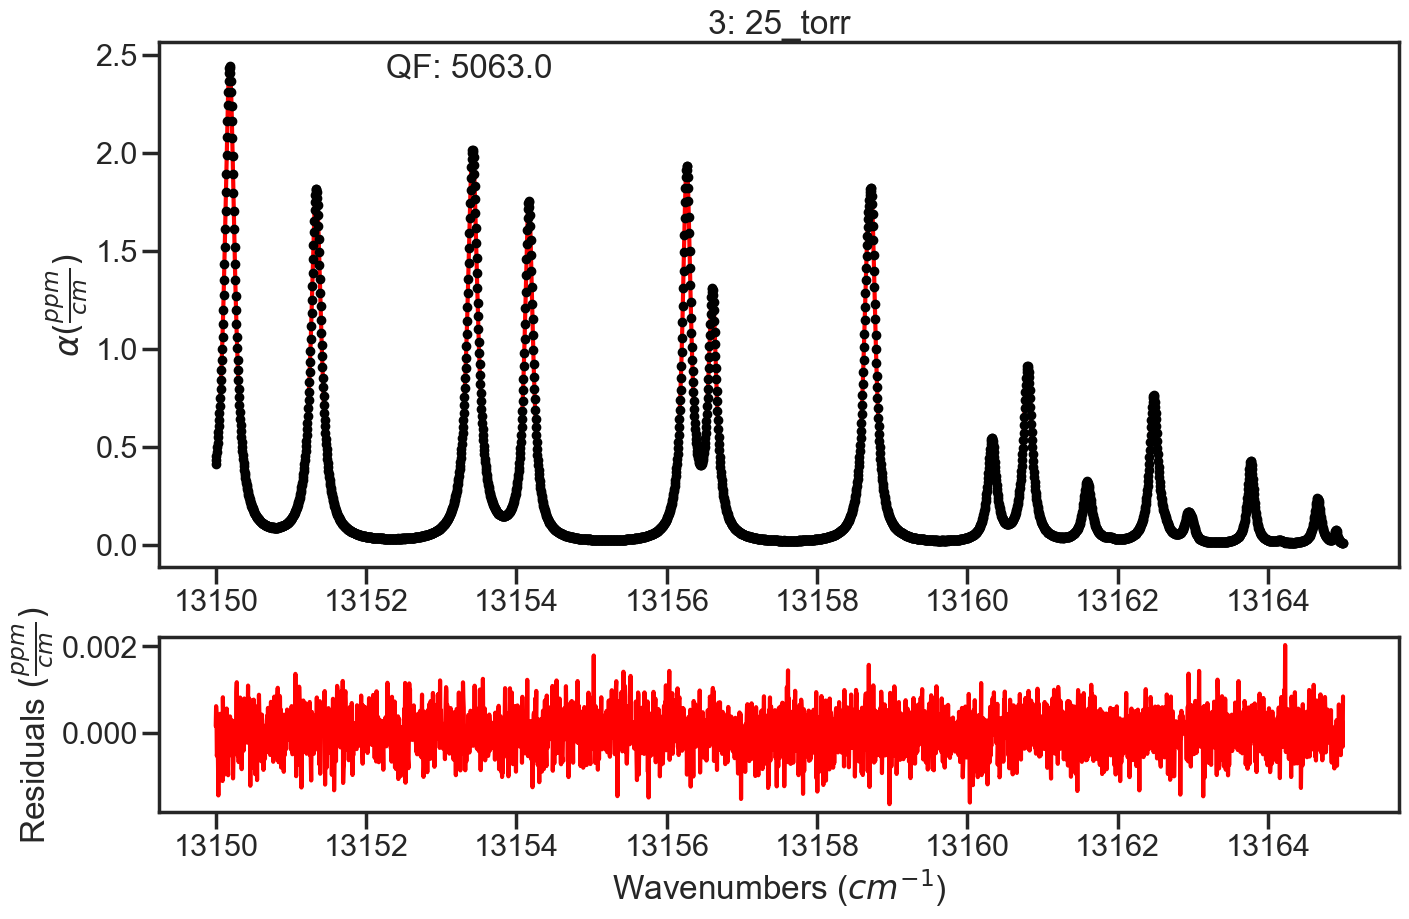

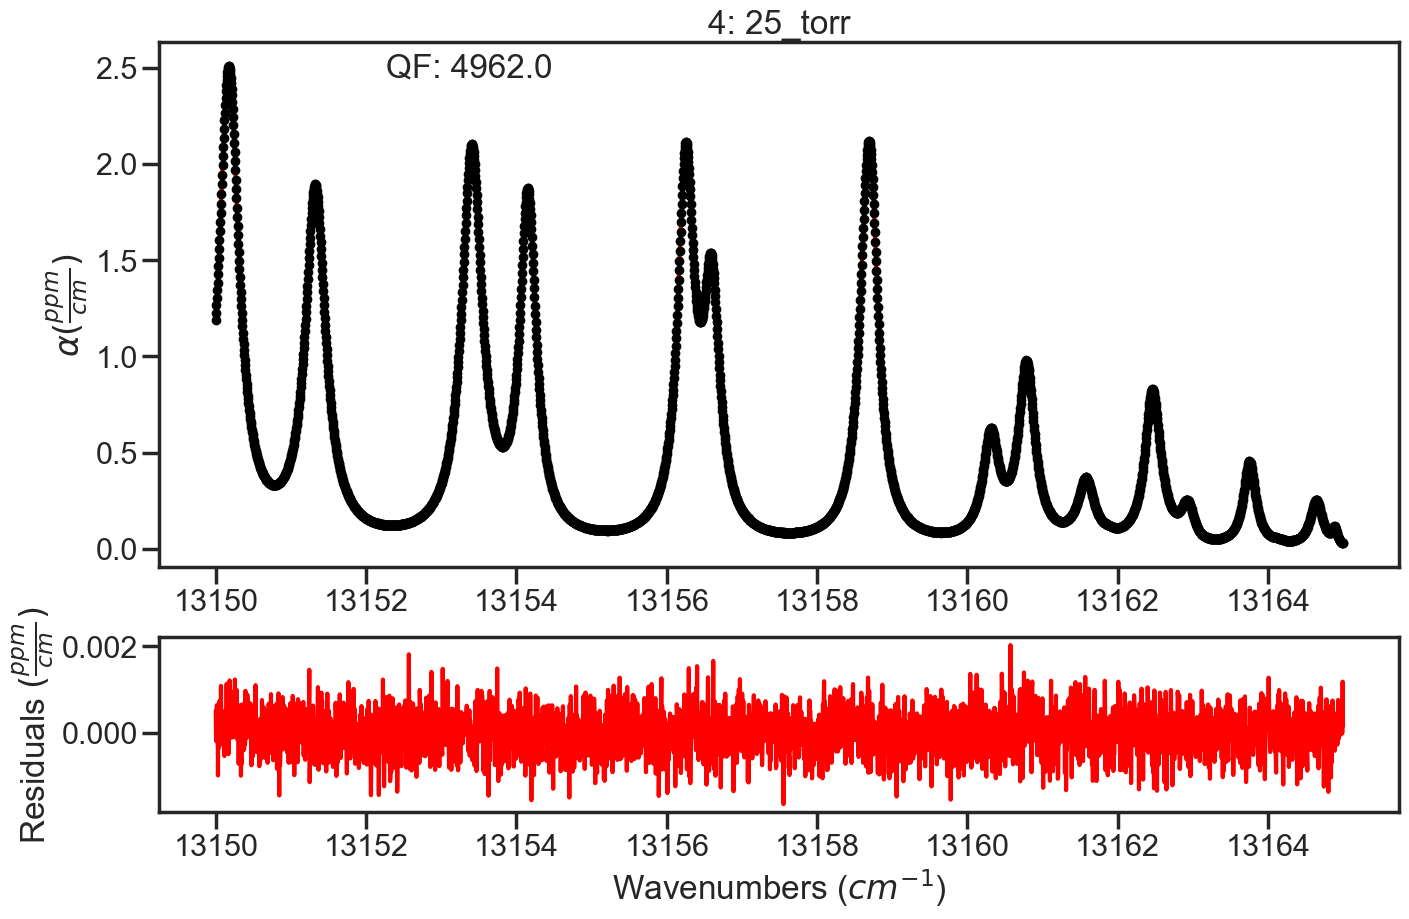

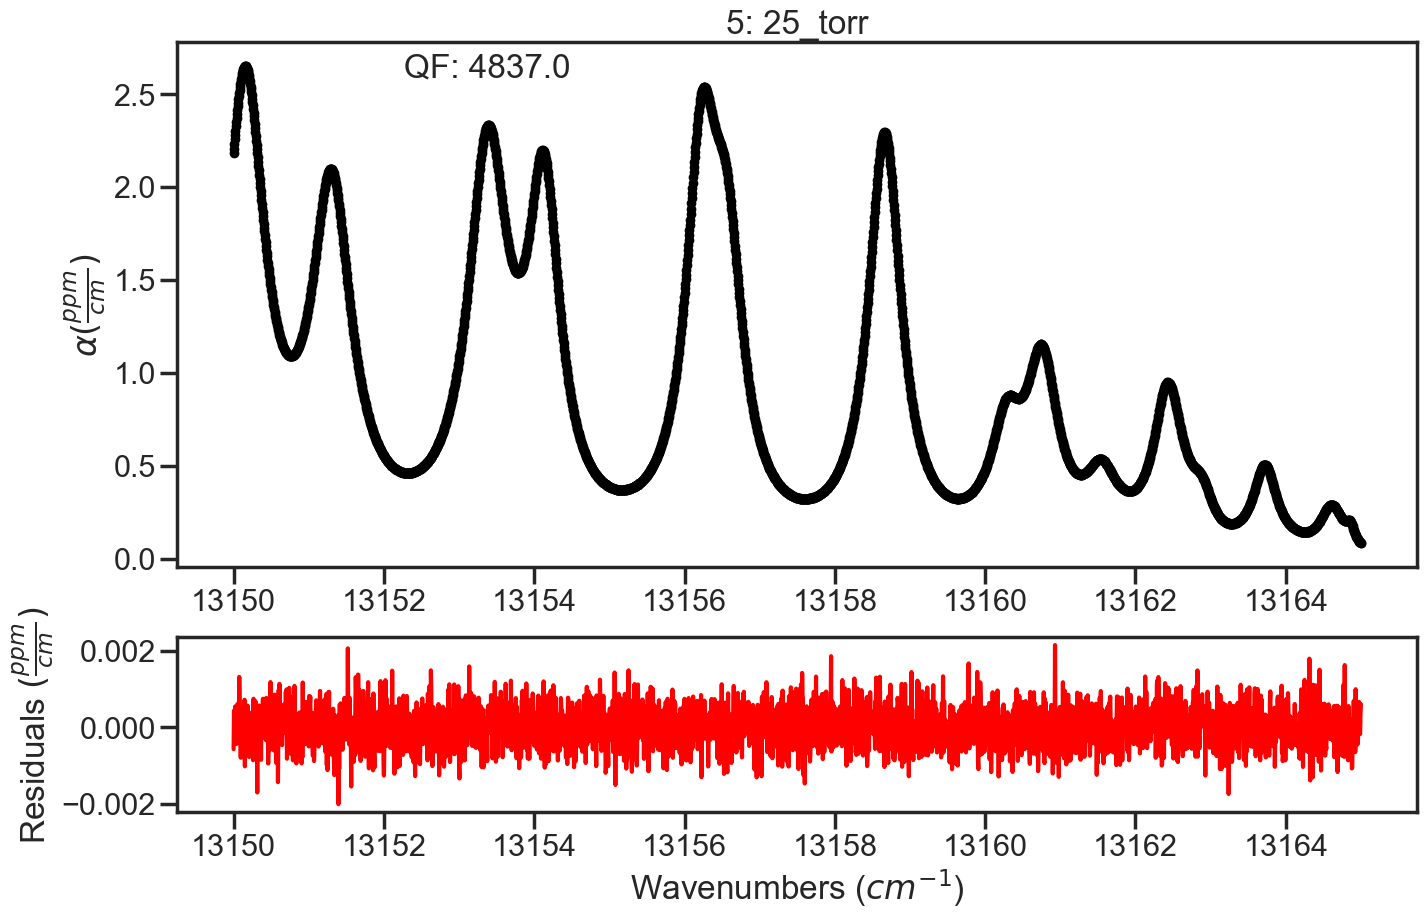

In [23]:
fit_data = MATS.Fit_DataSet(SPECTRA,'Baseline_LineList', 'Parameter_LineList', minimum_parameter_fit_intensity = Fit_Intensity/100, weight_spectra = False)


params = fit_data.generate_params()





result = fit_data.fit_data(params, wing_wavenumbers = 25, wing_method = 'wing_wavenumbers', 
                          method = 'least_squares') #least_squares is TRR and leastsq == LM

fit_data.residual_analysis(result, indv_resid_plot=True)

SPECTRA.generate_summary_file(save_file = True)
fit_data.update_params(result)
#SPECTRA.plot_model_residuals()

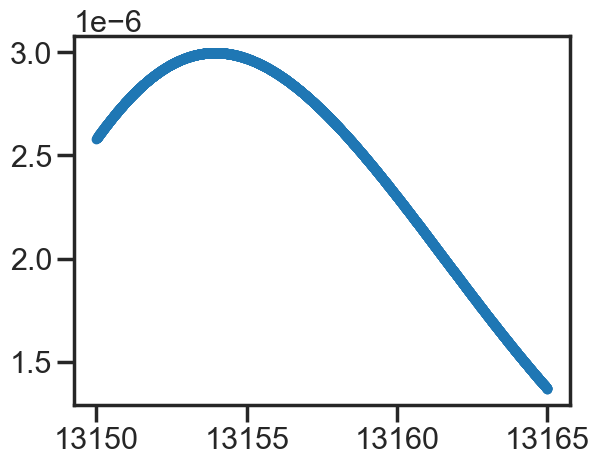

In [21]:
pressure = 5
PARAM_LINELIST['LineIntensity_BIA'] = PARAM_LINELIST['sw']*(1-0.01*PARAM_LINELIST['BIA_slope_air']*(5))
PARAM_LINELIST['Line Intenisty - LineIntensity_BIA'] =  PARAM_LINELIST['sw'] - PARAM_LINELIST['LineIntensity_BIA']
mol_dens =  (5/ MATS.codata.CONSTANTS['cpa_atm'])/(MATS.codata.CONSTANTS['k']*296)

wavenumbers = spec_5.wavenumber
BIA_FW = [0]*len(wavenumbers)

for i in PARAM_LINELIST.index:
    intensity = PARAM_LINELIST[PARAM_LINELIST.index ==i]['Line Intenisty - LineIntensity_BIA'].values[0]
    nu = PARAM_LINELIST[PARAM_LINELIST.index ==i]['nu'].values[0]
    time_constant = 0.75
    BIA_FW += intensity*mol_dens*MATS.hapi.PROFILE_LORENTZ(nu, 1/(2*np.pi*29979245800*1e-12*time_constant), 0, wavenumbers)
    
    
    

plt.plot(wavenumbers,BIA_FW, ".")
